# Lesson 121 · History of relational ML: rules, features, and graphs

Student lab · Three live TODO/CHECK tasks, prior-art map, and a separate complete visible Home Credit model/trainer. Default execution is COURSE_ONLY; full five-fold reproduction NOT_RUN.

In [ ]:
# @colab-bootstrap: install only missing default-lab packages and report versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','torch':'torch','sklearn':'scikit-learn'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual runtime:',sys.version)
print({n:importlib.metadata.version(n) for n in ['numpy','torch','scikit-learn']})
import json,sqlite3
from pathlib import Path


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 120 to this lesson</p>
<p>After assembling the pipeline, locate its choices among rules, engineered aggregates and learned message passing. The historical detour explains alternatives you must compare fairly.</p>
<details><summary>Quick prerequisite reminder</summary><p>An aggregate reduces a group of values, such as a sum per order. Changing the grouping can change the answer even when all original values remain present.</p></details>
</aside>
<!-- sequence-review:end -->



## The question that connects the history

**Your tangible win:** draw a defensible prior-art map and explain, with numbers and code, where each method puts the work of discovering useful relational information. The map is a history of different choices, not a ranking in which every newer method wins.

[Lesson 118](https://avistian.github.io/relational/lessons/0118-cvitkovic-relational-gnn.html) built Cvitkovic's model. [Lesson 120](https://avistian.github.io/relational/lessons/0120-year-3-exit-exam.html) asked you to defend a complete pipeline. We now ask why that pipeline exists. This grounds the mission: a claim that relational deep learning adds value needs to survive comparison with earlier ways of using the same relationships. Preparing this lesson does not certify that you passed the Year 3 exam.

**Route:** understand the historical map; trace one small database; implement three computations; audit what the reproduction establishes; write your own map. Work through one section at a time. The research and reproduction appendix can take a separate session.

Without notes: what does a foreign key preserve? Why can a flat feature vector lose a distinction? Why is author execution not learner mastery?

Open the [student notebook](https://avistian.github.io/relational/labs/0121-history-relational-ml.ipynb), [executed reference notebook](https://avistian.github.io/relational/labs/html/0121-history-relational-ml.html), and [quick reference](https://avistian.github.io/relational/reference/history-relational-ml.html). The notebook contains the visible mechanism code and full Cvitkovic model/trainer. It runs without the private competition data.



## 1 · Read the map as a set of design choices

A **relational database** stores rows in several tables. A **primary key** identifies a row. A **foreign key** names a related row in another table. A model must turn that variable-sized neighborhood into a prediction for a particular entity or query.

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">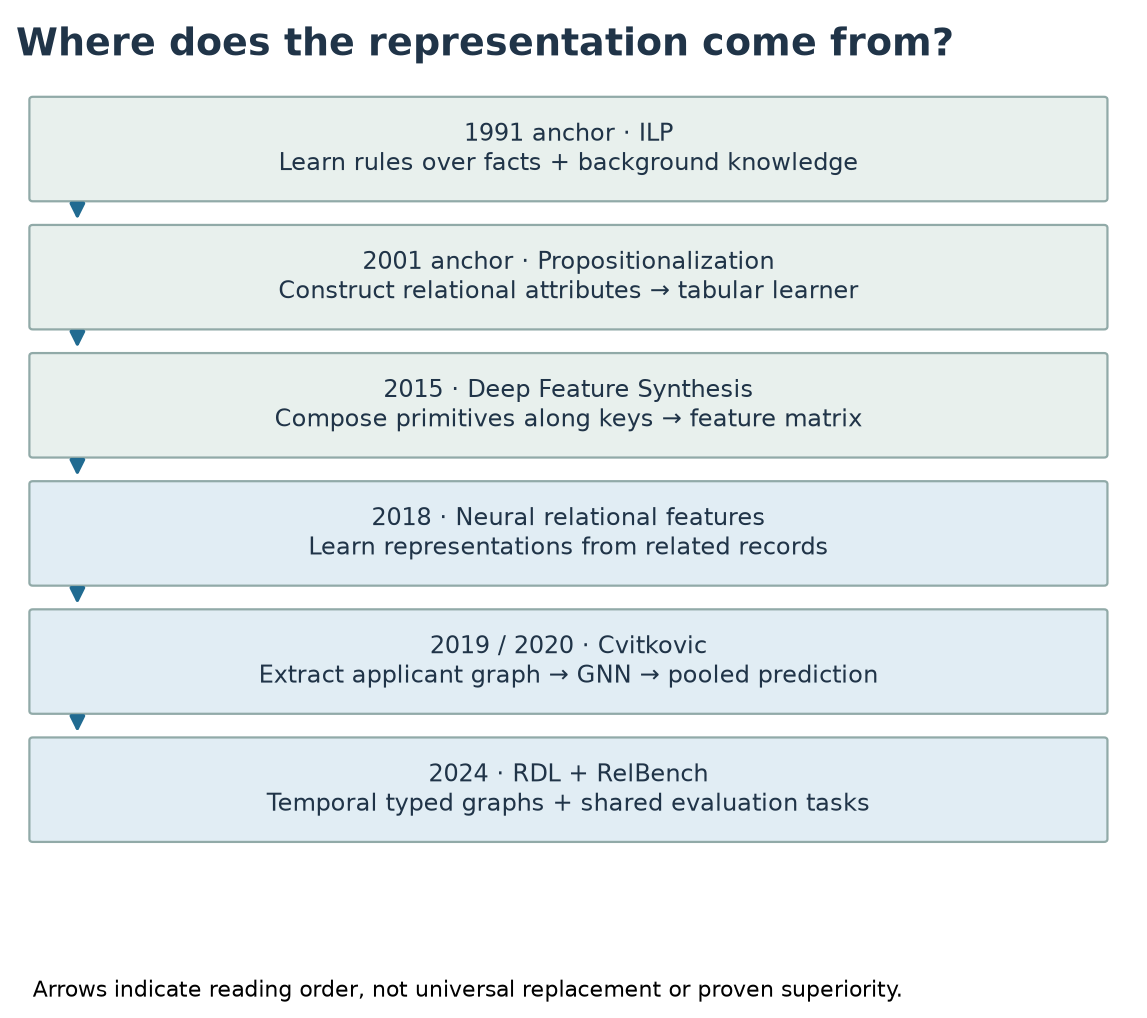<figcaption>Historical anchors and representation choices; reading order does not establish replacement. Scroll horizontally on narrow screens.</figcaption></figure>

| Historical anchor | What is constructed or learned? | Useful capability | Burden that remains |
|---|---|---|---|
| ILP, 1991 anchor | Logical rules over relations and background knowledge | Express explicit relational conditions | Choose vocabulary and constrain the rule search |
| Propositionalization, 2001 anchor | A fixed feature vector from relational descriptions | Reuse ordinary attribute-value learners | Decide which relational distinctions become features |
| Deep Feature Synthesis, 2015 | Compositions of feature primitives along relationships | Automate a large set of candidate features | Select primitives, depth, and a downstream estimator |
| Neural relational feature learning, 2018 | Learned representations from relational data | An earlier neural route in this history | Audit its own architecture and evaluation scope |
| Cvitkovic, 2019 / expanded 2020 | Row encoders, graph computation, pooled prediction | Train representation and predictor together | Extraction, scale, and experimental comparability |
| Fey and RelBench, 2024 | Temporal heterogeneous graph blueprint and shared tasks | Make pipelines and evaluation more systematic | Preserve query-time validity and compare strong baselines |

The dates are anchors for the readings, not claims that an entire family began that year. ILP and feature engineering remain useful. Neural relational learning also predates the selected GNN paper: [Lam et al. 2018](https://arxiv.org/abs/1801.05372) is a necessary branch on the map. Do not write “relational learning began with GNNs.”

**Primary readings:** [Muggleton 1991, §§1–2](https://www.doc.ic.ac.uk/~shm/Papers/ilp.pdf), [Lavrač and Flach 2001](https://research-information.bris.ac.uk/en/publications/an-extended-transformation-approach-to-inductive-logic-programmin/), and [Kanter and Veeramachaneni 2015, §II and Algorithm 1](https://www.jmaxkanter.com/papers/DSAA_DSM_2015.pdf). For the selected neural experiment, read [Cvitkovic 2020, §§3–5 and Appendix B](https://arxiv.org/html/2002.02046v1).



## 2 · Start with a rule you can execute

**In plain terms.** A relational rule can ask whether a related row with a particular property exists. It need not flatten every possible child into a separate input column.

**Worked example.** Customer 7 has orders 11 and 12. Order 11 is on time; order 12 is late. Customer 8 has late order 13. Customer 9 has no orders. Write the condition “a customer has a late order” as:

```text
has_late_order(customer) ← owns(customer, order) AND late(order)
```

The arrow means the condition on the right is sufficient for the statement on the left. `order` is an existential variable: at least one matching order is enough. The outputs for customers `[7,8,9]` are `[True,True,False]`.

**Inductive logic programming (ILP)** learns logical programs using examples and background knowledge. Executing the rule above is deduction: apply an already supplied rule to facts. Learning which rule to use is induction. Our first exercise executes a rule; it does not implement an ILP search engine. This distinction follows the setting introduced by [Muggleton](https://www.doc.ic.ac.uk/~shm/Papers/ilp.pdf).

**TODO 1 — `exists_late`:** return one Boolean per requested customer, in query order. Check empty neighborhoods, row permutations, and the difference between “has an order” and “has a late order.” Duplicate matching orders must not change an existential answer.

**Pause and retrieve.** Which part would an ILP system have to discover that this exercise receives as an input? Answer before moving on: the rule itself, rather than only its truth value on the database.



## 3 · Turn relations into columns, then automate the construction

**Propositionalization** turns relational information into a fixed set of attributes for each prediction example. A Boolean `has_late_order` can itself be one such attribute. The transformation makes existing tabular learners usable; its usefulness depends on what the attributes preserve. [Lavrač and Flach](https://research-information.bris.ac.uk/en/publications/an-extended-transformation-approach-to-inductive-logic-programmin/).

**Worked example.** Suppose customer 7 has transaction amounts 2 and 4 available by day 5. The vector `[COUNT, SUM, MAX]` is `[2,6,4]`. A third amount 8 happened on day 4 but arrived on day 7. At day 5, including it would use information that had not arrived. At day 7 the vector becomes `[3,14,8]`.

**TODO 2 — `aggregate_at`:** filter each row using both `event_time <= cutoff` and `available_time <= cutoff`, then compute count, sum and maximum. Use `[0,0,0]` for an empty group in this authored example. Preserve query order. The CHECK compares your result with an independent SQL query. In real features, an empty maximum needs an explicit missing-value convention; zero is a teaching choice here.

**Deep Feature Synthesis (DFS)** automates candidate feature construction by composing operations along table relationships. A **primitive** is a basic operation such as sum or a date transformation. The word “deep” refers to composing these operations; it does not imply a neural network. The original [DFS paper, §II](https://www.jmaxkanter.com/papers/DSAA_DSM_2015.pdf) explains the construction. Current [Featuretools documentation](https://featuretools.alteryx.com/en/stable/getting_started/afe.html) illustrates stacked aggregates.

Our hand-written aggregate is one feature recipe. It does not enumerate a DFS feature space or reproduce the Data Science Machine's tuning. Distinguish the algorithm that proposes features from the estimator fitted on their resulting values.

### Preserve the intermediate grouping

**Predict first:** can two customers have the same transaction count, sum, and maximum, but different distributions of spending across orders?

Static trace: A has two order totals [2,8], B has one [10]. Flat vectors agree at [2,10,8]. Nested sum of squares gives 68 versus 100. Splitting B into two orders changes its nested result to 68.

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">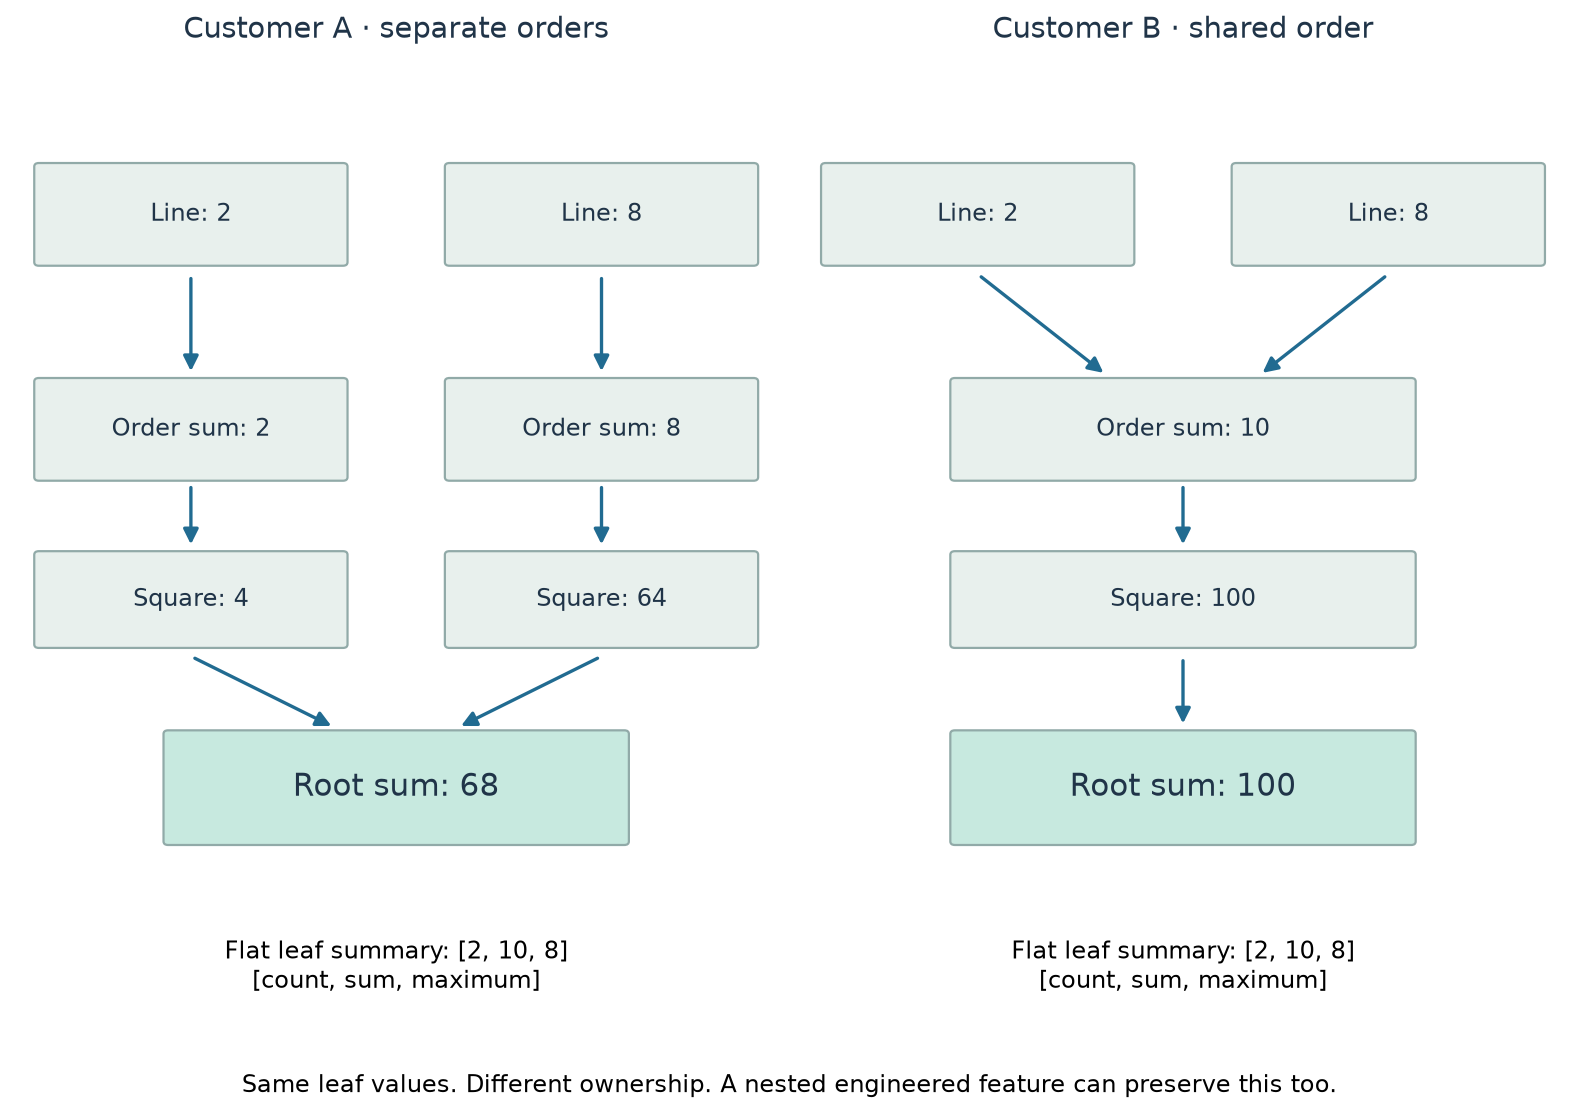<figcaption>Same line values [2,8], different order ownership. Flat [count,sum,max] agrees; nested sums of squares yield 68 and 100. Scroll horizontally on narrow screens.</figcaption></figure>

**Worked example.** Both customers have line amounts `[2,8]`, so both have `[COUNT,SUM,MAX] = [2,10,8]`. Customer A places them in two orders: order totals `[2,8]`. Customer B places both in one order: total `[10]`. Now compute the sum of squared order totals. For A, `2² + 8² = 68`. For B, `10² = 100`.

The two-stage recipe is: group lines by order; sum their amounts; square each order total; group orders by customer; sum again. Squaring before the second grouping retains a distinction that a single global sum would erase.

**A repair is available to both families.** An engineered nested feature can explicitly compute this recipe. A suitable graph computation can also preserve the intermediate order states. This example establishes a limitation of the three selected flat features, not a universal advantage of GNNs over feature engineering.



## 4 · Follow the same path as a differentiable computation

A **message** is a value passed from one node to another along an edge. An **aggregation** combines the messages received by a node. A **differentiable** computation allows derivatives of an output with respect to its inputs or parameters to be calculated through the operations.

**TODO 3 — `path_signal`:** implement the exact numerical recipe from the figure using tensor accumulation. First create an `[n_orders,1]` array of zeros. Sum each line amount into its order. Square the order totals. Sum these into an `[n_customers,1]` array. The code must use the ownership indices supplied to it, not a global mean or the order of the input rows.

```python
order_values.index_add_(0, leaf_order, values)
root_values.index_add_(0, order_root, order_values.square())
```

`index_add_` accumulates every source row into its indexed destination. Repeated destination indices mean addition, not replacement. The first operation follows Line→Order. The second follows Order→Customer. The completed function runs directly in the notebook experiment and its gradient check.

**Trace the gradient.** Customer A's output is `x₁²+x₂²`. At inputs 2 and 8, its derivatives are 4 and 16. Customer B's lines receive zero derivative from A's output because no ownership path connects them to A. The CHECK tests that separation and invariance to line-row permutations.

> **Scope check.** This fixed square operator has no learned parameters. It exposes a path that a learned message-passing model can use; it is not Cvitkovic's GCN. Adding learnable weights does not automatically guarantee that training will discover a useful representation.



## 5 · What changed with the selected Cvitkovic model?

The [2019 workshop version](https://rlgm.github.io/papers/55.pdf) and [expanded February 2020 version](https://arxiv.org/abs/2002.02046v1) are separate source objects. The latter supplies our Home Credit experiment. Its Table 4 reports GCN AUROC **0.780 ± 0.004** and DFS+GBDT **0.777 ± 0.004** on Home Credit. AUROC measures ranking of positive versus negative cases; larger is better. These are published values, not results of this lesson.

The paper reports an advantage over automated feature engineering on two of three datasets. Its KDD Cup result is counter-evidence to a universal-win story. Small mean differences and fold variation alone do not establish statistical superiority. [Expanded paper, Table 4](https://arxiv.org/html/2002.02046v1).

### Model architecture: read the actual prediction path

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">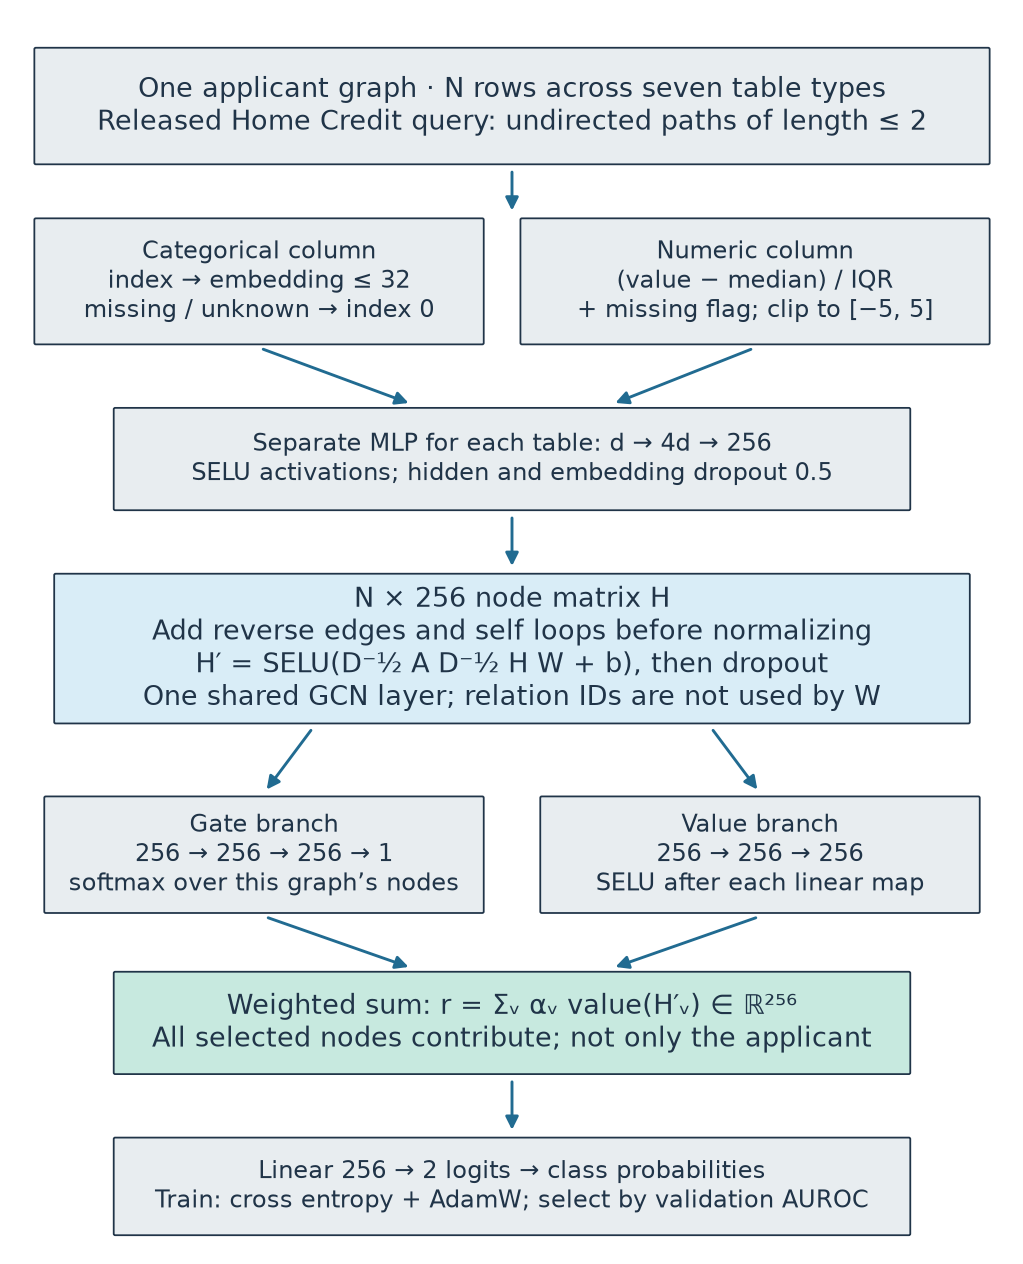<figcaption>Selected Home Credit GCN: table-specific encoders, one shared GCN, graph-local gate/value pooling, and two logits. Reused from Lesson 118. Scroll horizontally on narrow screens.</figcaption></figure>

**Diagram trace.** Locate the shared graph convolution and the graph-specific pooling. Which computation is inherited from Lesson 118? On a narrow screen, scroll the figure sideways.

Read the diagram from the applicant graph downward. Table-specific encoders turn categorical and numerical row values into 256-dimensional vectors. Reverse edges and self-loops support a shared GCN computation. A gate branch assigns graph-local weights; a value branch transforms node states. Their weighted sum produces one graph representation and a two-logit classifier output. A **logit** is a score before conversion to a class probability. The pooling reads all selected nodes.

**Decode the computation.** In the diagram, `N` is the number of selected rows and `H` is their `N×256` state matrix. `A` records incoming computation edges, including added reverse edges and self-loops. `D` is the diagonal matrix of node degrees. Multiplying by `D⁻½ A D⁻½` sums neighbors with a weight of `1/sqrt(degree_source × degree_receiver)` on each edge. `W` and `b` are learned weights and a bias. SELU is a nonlinear activation, applied coordinate by coordinate. Dropout randomly suppresses coordinates during training and is disabled for evaluation.

**Follow the readout.** The gate branch produces one scalar per node. Softmax exponentiates these scalars and divides by their sum within that applicant graph, yielding weights `αᵥ` that sum to one. The value branch produces a 256-coordinate vector per node. The sum `r = Σᵥ αᵥ value(H′ᵥ)` is therefore one 256-coordinate applicant representation. The classifier maps it to two scores. Cross-entropy penalizes low probability on the true class; AdamW uses gradients to update model parameters. Validation AUROC chooses a checkpoint, while test-fold AUROC evaluates the chosen checkpoint. The normalization operation and full forward code are visible in the notebook.

The notebook inlines the complete selected model and trainer from the [pinned released-code port](https://avistian.github.io/relational/labs/relkit/cvitkovic_l118.py), in annotated sections. Follow `RowEncoder`, `CvitkovicGCN`, `attention_pool`, and `fit_fold`. The exact released choices and modern-runtime differences are in the [L118 protocol](https://avistian.github.io/relational/labs/l118-reproduction.md). There is no need to infer an implementation from a generic GNN box.

### Extraction is part of the model's input contract

The paper's general two-phase RDBToGraph procedure and the released Home Credit query are different procedures. Home Credit uses undirected paths of length zero through two around an applicant. The returned graph contains the nodes and relationships visited by those paths. Do not silently replace that with arbitrary closure or assume every induced edge was returned. [Released extraction code](https://github.com/mwcvitkovic/Supervised-Learning-on-Relational-Databases-with-GNNs/blob/57195ccab62d23dcbcac1a317f8a9811a9fd6cb5/data/homecreditdefaultrisk/build_dataset_from_database.py).

A reproducible model result needs the right graph, feature conversion, folds, training schedule, selection rule, and scoring. The original source even creates a payment's applicant edge before attempting to match its previous application. A missing previous key does not undo the already-created edge. That detail motivates our fresh extraction audit.



## 6 · Read the reproduction evidence without upgrading it

**Full five-fold Home Credit experiment: NOT_RUN.** No fresh held-out AUROC is claimed.

| Evidence | Measured result | Boundary |
|---|---|---|
| Original course grouping computation | 68 versus 100 | Fixed operator, not trained GCN accuracy |
| Raw previous-application key universe | 1,670,214 keys scanned | 32 selected applicants |
| Missing previous references in that sample | 14 globally absent; 0 cross-owner | Missing relation is not a dropped applicant edge |
| Original Neo4j extraction comparison | PASS after empty→null correction | 32 applicants; full-population equivalence NOT_CHECKED |
| Raw categorical cells corrected | 123 | Encoded tensors unchanged; original raw mismatch preserved in audit |
| Cached tensor/output/gradient check | EXACT on eight real graphs | Controlled computation, current runtime |
| Fresh cached timing pilot | 1,024 graphs; 130,886 nodes | Fixed reconstructed batch, no score evaluation |
| Cached batch collation median | 0.0434 seconds | Original preparation 1.490 seconds |
| Five-fold maximum-schedule projection | USD 15.70 | Excludes full cache construction, disk IO and overhead |
| Aggregate cap / overhead reserve | USD 10 / USD 2 | Pilot worker reservation USD 0.406296 |

The improved projection still exceeds the cap. **Decision: do not launch five folds.** Pilot function-body resource estimate: USD 0.002409; unitemized startup/build costs are separate. Historical training identity and whole-paper parity remain NOT_ESTABLISHED. Live Colab and deployment remain NOT_CHECKED.

[Extraction audit](https://avistian.github.io/relational/labs/_neo4j_l121_results.json) · [Raw-key audit](https://avistian.github.io/relational/labs/_data_l121_results.json) · [Cache check](https://avistian.github.io/relational/labs/_cache_check_l121_results.json) · [Timing evidence](https://avistian.github.io/relational/labs/_pilot_l121_results.json) · [Budget](https://avistian.github.io/relational/labs/_budget_l121.json).


**Selected target:** all 307,511 labeled applications, five released cross-validation folds, model seed 1234 reset per fold, maximum 300 epochs with patience 50, first-best validation AUROC, full test-fold scoring. The five folds are different held-out partitions, not five independent random-seed runs. The predeclared mean comparison tolerance is 0.01 AUROC; it is descriptive, not a statistical equivalence test.

**Optimization boundary.** We cache deterministic scalar/category conversion and graph indices. We do not cache learned embeddings, dropout masks, or model outputs. A controlled check requires identical tensors, training outputs, and gradients under the same random state. This supports the cache transformation, not full training parity.

**Budget boundary.** One bounded pilot is reserved before dispatch. The all-fold projection includes the maximum schedule and final tests, with separate startup/retry reserve. Early stopping might reduce runtime, but we do not launch on an optimistic assumption. The [reproduction contract](https://avistian.github.io/relational/labs/l121-reproduction.md) contains exact commands, source hashes, runtime pins, and remaining gaps. It also explains how the full-data runner refuses missing inputs or insufficient budget.

**Exercise.** Classify each statement as paper claim, measured source/implementation evidence, course mechanism result, or unestablished claim: “68 versus 100,” “the cached tensors agree,” “Home Credit AUROC is .780,” and “we reproduced all five folds.” Give the supporting artifact for each valid statement. The last statement is not supported here.



## 7 · Why Year 4 needs a temporal evaluation standard

The [Fey 2024 blueprint](https://proceedings.mlr.press/v235/fey24a.html) describes relational data as a temporal heterogeneous graph: nodes represent rows, and typed links follow key relationships. **Heterogeneous** means node or edge types have different meanings. This provides a common modeling vocabulary. [RelBench v1](https://arxiv.org/abs/2407.20060) supplies shared datasets, tasks, and evaluation protocols.

This is a shift in infrastructure and evaluation, not proof that earlier approaches never handled time. Feature engineering can respect cutoffs too. Our both-clock exercise illustrates a stricter availability contract; missing historical ingestion logs still limit what any retrospective audit can establish.

Lesson 122 will ask you to construct the relational entity graph from a schema. Carry forward three questions: which rows are visible for this query, which relationships are retained, and which computation can use them? The answer must be explicit before training starts.

Explain why a nested engineered feature can repair this flat collision, and why relational learning predates this GNN. Compare your explanation with the historical map.



## 8 · EXIT: build your own prior-art map

Complete the [map and defense template](https://avistian.github.io/relational/labs/l121-prior-art-map.md). For each historical anchor, record the input representation, what is learned, where human choices enter, one primary source, and one limitation. Add a separate branch for the 2018 neural work. Attach your three implemented functions and notebook report.

Explain the 68-versus-100 example without notes. Then give an engineered feature that repairs the flat collision. Finally, explain why neither an extraction check nor a fast pilot establishes a reproduced AUROC. Cite one result that supports the mission and one that limits it.

**Exit criterion:** correct computation, a sourced map, a fair baseline repair, and an evidence claim that survives the stated boundaries. Author execution does not mark your mastery: **PENDING_WRITTEN_DEFENSE**.

In 1, 7, and 30 days, redraw the map and recompute the grouping example from memory. Ask the agent follow-up questions wherever a historical claim, ownership index, or reproduction decision remains unclear.

<!-- sequence-next:start -->
**Carry this forward.** Construct the row graph and verify every edge against a relational join. [Continue to Lesson 122](https://avistian.github.io/relational/lessons/0122-reg-construction.html).
<!-- sequence-next:end -->


## Live tasks · original course mechanisms

Implement each function before its CHECK. These are rule evaluation, a feature recipe, and a fixed differentiable ownership path. They are not full ILP/DFS search or the paper GCN. The RUN calls your definitions directly.

### Imports and scope · PROVIDED

In [ ]:
"""Original course computations, not implementations of full ILP or DFS search."""
import numpy as np
import torch

### Task 1: evaluate an existential relational rule

**TODO:** Evaluate existence of a matching late order; preserve query order.

In [ ]:
def exists_late(rows, roots):
    raise NotImplementedError("TODO: exists_late")

In [ ]:
def check_rule(fn):
 rows=[(11,7,0),(12,7,1),(13,8,1)] # order, customer, late
 assert fn(rows,[7,8,9])==[True,True,False], 'An existential rule needs one matching child; empty is false.'
 assert fn([(11,7,0)],[7,8])==[False,False], 'Do not confuse existence of an order with existence of a late order.'
 assert fn(rows[::-1],[8,7])==[True,True], 'Query order matters, row order does not.'
check_rule(exists_late)
print("PASS: exists_late")

### Task 2: construct query-time aggregate features

**TODO:** Filter with both clocks, then construct count, sum, and maximum.

In [ ]:
def aggregate_at(rows, roots, cutoff):
    raise NotImplementedError("TODO: aggregate_at")

In [ ]:
def check_aggregate(fn):
 # id, customer, amount, event, available; the late-arriving row is excluded at day 5.
 rows=[(11,7,2.,2,2),(12,7,8.,4,7),(13,8,3.,3,3),(14,7,4.,4,4)]
 got=fn(rows,[8,7,9],5)
 assert np.allclose(got,[[1,3,3],[2,6,4],[0,0,0]]), 'Use both clocks, preserve root order, define empty aggregates.'
 assert np.allclose(fn(rows,[7],7),[[3,14,8]]), 'Late arrival becomes usable once both clocks permit it.'
 con=sqlite3.connect(':memory:');con.execute('CREATE TABLE events(id,c,amount,event,available)');con.executemany('INSERT INTO events VALUES(?,?,?,?,?)',rows)
 expected=[con.execute('SELECT COUNT(*),COALESCE(SUM(amount),0),COALESCE(MAX(amount),0) FROM events WHERE c=? AND event<=? AND available<=?',(c,5,5)).fetchone() for c in [8,7,9]]
 assert np.allclose(got,expected),'Independent SQL aggregate mismatch';con.close()
check_aggregate(aggregate_at)
print("PASS: aggregate_at")

### Task 3: preserve the intermediate grouping in a two-hop computation

**TODO:** Accumulate lines into orders, square order totals, then accumulate into customers.

In [ ]:
def path_signal(values, leaf_order, order_root, n_orders, n_roots):
    raise NotImplementedError("TODO: path_signal")

In [ ]:
def check_path(fn):
 # leaf values [2,8] belong to separate orders, [5,5] to one order.
 x=torch.tensor([[2.],[8.],[5.],[5.]],requires_grad=True)
 leaf_order=torch.tensor([0,1,2,2]);order_root=torch.tensor([0,0,1]);out=fn(x,leaf_order,order_root,3,2)
 assert torch.allclose(out,torch.tensor([[68.],[100.]])), 'Sum within each order, square, then sum into roots.'
 out[0].sum().backward();assert torch.allclose(x.grad,torch.tensor([[4.],[16.],[0.],[0.]])), 'Supervision must follow the two-hop ownership path.'
 perm=torch.tensor([3,0,2,1]);assert torch.allclose(fn(x.detach()[perm],leaf_order[perm],order_root,3,2),out.detach()),'Permutation invariance failed.'
check_path(path_signal)
print("PASS: path_signal")

## RUN · compare the actual live computations

Predict the day-5/day-7 vectors and 68/100 outputs before running. All values are authored course examples; no predictive model comparison is implied.

In [ ]:
rules=exists_late([(11,7,0),(12,7,1),(13,8,1)],[7,8,9])
rows=[(11,7,2.,2,2),(12,7,8.,4,7),(13,8,3.,3,3),(14,7,4.,4,4)]
features_day5=aggregate_at(rows,[8,7,9],5)
features_day7=aggregate_at(rows,[8,7,9],7)
values=torch.tensor([[2.],[8.],[2.],[8.]],requires_grad=True)
path=path_signal(values,torch.tensor([0,1,2,2]),torch.tensor([0,0,1]),3,2)
path[0].sum().backward()
assert path.flatten().tolist()==[68.,100.]
assert np.array_equal(features_day5,[[1,3,3],[2,6,4],[0,0,0]])
report={'status':'PASS','evidence':'COURSE_ONLY','rule':rules,'day5_features':features_day5.tolist(),'day7_features':features_day7.tolist(),'path_outputs':path.flatten().tolist(),'root_A_input_gradients':values.grad.flatten().tolist(),'paper_result':'NOT_RUN','learner':'PENDING_WRITTEN_DEFENSE'}
Path('l121-task-report.json').write_text(json.dumps(report,indent=2));print(report)


## PROVIDED · full selected Home Credit implementation

These annotated definitions are the visible L118 modern port used by the source checks and real-data pilot. The original source is MIT licensed and pinned at 57195ccab62d23dcbcac1a317f8a9811a9fd6cb5. The DGL primitive references are Apache-2.0. Read the protocol and original licenses in the repository. The full trainer requires trusted locally prepared data and is not called by default.

### PROVIDED · Imports and execution contract

In [ ]:
"""Cvitkovic Home Credit GCN port. Original MIT code is pinned in sources/l118.
Graph mechanics are visible PyTorch; real-data extraction uses the released prepared format.
A completed toy run is COURSE_ONLY. Five-fold paper replay is a separate explicit command.
"""
import copy
import hashlib
import json
import math
import pickle
import time
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, train_test_split

### PROVIDED · Task 1: two ordered reachability phases

In [ ]:
def rdb_to_graph(n_nodes, edges, target):
    if not 0 <= target < n_nodes:
        raise ValueError('target outside graph')
    incoming=[[] for _ in range(n_nodes)];outgoing=[[] for _ in range(n_nodes)]
    for u,v in edges:
        if not (0 <= u < n_nodes and 0 <= v < n_nodes):
            raise ValueError('edge outside graph')
        outgoing[u].append(v);incoming[v].append(u)
    selected={target}
    for adjacency in [incoming,outgoing]:
        queue=list(selected)
        while queue:
            u=queue.pop()
            for v in adjacency[u]:
                if v not in selected:
                    selected.add(v);queue.append(v)
    return sorted(selected),[(u,v) for u,v in edges if u in selected and v in selected]

### PROVIDED · Task 2: normalized message aggregation

In [ ]:
def normalized_sum(x, edges):
    # The release collator already supplied reverse edges and self loops.
    src,dst=edges
    degree=torch.bincount(dst,minlength=len(x)).to(x.dtype).clamp_min(1)
    norm=degree.rsqrt()
    output=torch.zeros_like(x)
    output.index_add_(0,dst,x[src]*norm[src,None])
    return output*norm[:,None]

### PROVIDED · Task 3: graph-local gated pooling

In [ ]:
def attention_pool(values, gates, batch, n_graphs):
    gates=gates.reshape(-1)
    if (torch.bincount(batch,minlength=n_graphs)==0).any():
        raise ValueError('empty graph cannot be pooled')
    maximum=gates.new_full((n_graphs,),-torch.inf)
    maximum.scatter_reduce_(0,batch,gates,reduce='amax',include_self=True)
    exponent=torch.exp(gates-maximum[batch])
    denominator=gates.new_zeros(n_graphs).index_add_(0,batch,exponent)
    weights=exponent/denominator[batch]
    return values.new_zeros((n_graphs,values.shape[1])).index_add_(0,batch,weights[:,None]*values)

### PROVIDED · Graph construction: stored edges differ from computation edges

In [ ]:
def computation_edges(n_nodes, stored_edges):
    edges=list(stored_edges)
    edges=edges+[(v,u) for u,v in edges]+[(i,i) for i in range(n_nodes)]
    return torch.tensor(edges,dtype=torch.long).T.contiguous()


def undirected_hops(n_nodes,edges,target,hops=2,available=None,cutoff=None):
    """Home Credit's radius selection; optional time filter is a COURSE extension."""
    adjacency=[set() for _ in range(n_nodes)]
    for u,v in edges:adjacency[u].add(v);adjacency[v].add(u)
    selected={target};front={target}
    for _ in range(hops):
        candidates={v for u in front for v in adjacency[u]}
        front={v for v in candidates-selected if available is None or available[v] is None or available[v]<=cutoff}
        selected|=front
    return sorted(selected)

### PROVIDED · Feature preprocessing: released metadata, no target column

In [ ]:
def scalar_encode(values,center,scale):
    # Reproduce float32 input, missing flag, epsilon, and clipping in ScalarRescaleEnc.
    vals=np.array([np.nan if v is None else float(v) for v in values],dtype=np.float32)
    missing=np.isnan(vals)
    vals-=center;vals/=scale;vals+=1e-7
    vals[missing]=0
    return torch.from_numpy(np.column_stack([vals,missing.astype(np.float32)]).clip(-5,5))


def feature_schema(info):
    spec={}
    for table,features in info['node_types_and_features'].items():
        cards=[];n_cont=0
        for name,meta in features.items():
            if table+'.'+name==info['label_feature']:continue
            if meta['type']=='CATEGORICAL':cards.append(len(meta['sorted_values'])+1)
            elif meta['type']=='SCALAR':n_cont+=2
            else:raise ValueError('Home Credit port only covers its scalar/categorical columns')
        spec[table]=(cards,n_cont)
    return spec


def encode_features(raw,info):
    result={}
    for table,features in raw.items():
        cats=[];cont=[]
        for name,meta in info['node_types_and_features'][table].items():
            if table+'.'+name==info['label_feature']:continue
            values=features[name]
            if not values:continue
            if meta['type']=='CATEGORICAL':
                mapping={v:i+1 for i,v in enumerate(meta['sorted_values'])}
                cats.append(torch.tensor([mapping.get(v,0) for v in values],dtype=torch.long))
            elif meta['type']=='SCALAR':cont.append(scalar_encode(values,meta['RobustScaler_center_'],meta['RobustScaler_scale_']))
            else:raise ValueError(meta['type'])
        if cats or cont:
            n=len(cats[0]) if cats else len(cont[0])
            result[table]=(torch.stack(cats,dim=1) if cats else torch.empty(n,0,dtype=torch.long),torch.cat(cont,dim=1) if cont else torch.empty(n,0))
    return result

### PROVIDED · Table-specific initializers: embeddings then d -> 4d -> hidden

In [ ]:
class RowEncoder(nn.Module):
    def __init__(self,cards,n_cont,hidden=256,dropout=.5):
        super().__init__()
        self.embeddings=nn.ModuleList([nn.Embedding(c,min(32,c)) for c in cards])
        for embedding in self.embeddings:embedding.weight.data.clamp_(-2,2)
        self.dropout=nn.Dropout(dropout)
        width=sum(min(32,c) for c in cards)+n_cont
        self.layers=nn.Sequential(nn.Linear(width,4*width),nn.SELU(),nn.Dropout(dropout),nn.Linear(4*width,hidden),nn.SELU())
    def forward(self,cat,cont):
        parts=[self.dropout(e(cat[:,i])) for i,e in enumerate(self.embeddings)]
        if cont.shape[1]:parts.append(cont)
        return self.layers(torch.cat(parts,dim=1))

### PROVIDED · Model architecture: one shared GCN, two readout branches, two logits

In [ ]:
class CvitkovicGCN(nn.Module):
    def __init__(self,schema,type_ids,hidden=256,dropout=.5):
        super().__init__();self.type_ids=type_ids;self.hidden=hidden
        self.encoders=nn.ModuleDict({t:RowEncoder(cards,n,hidden,dropout) for t,(cards,n) in schema.items()})
        # Match original construction order: row encoders, readout, head, then GCN.
        self.gate=nn.Sequential(nn.Linear(hidden,hidden),nn.SELU(),nn.Linear(hidden,hidden),nn.SELU(),nn.Linear(hidden,1))
        self.value=nn.Sequential(nn.Linear(hidden,hidden),nn.SELU(),nn.Linear(hidden,hidden),nn.SELU())
        self.head=nn.Linear(hidden,2)
        self.weight=nn.Parameter(torch.empty(hidden,hidden));self.bias=nn.Parameter(torch.zeros(hidden))
        nn.init.xavier_uniform_(self.weight)
        self.dropout=nn.Dropout(dropout)
    def forward(self,features,node_types,edges,batch,n_graphs):
        h=self.weight.new_zeros((len(node_types),self.hidden))
        for table,(cat,cont) in features.items():h[node_types==self.type_ids[table]]=self.encoders[table](cat,cont)
        # Equal in/out widths: DGL 0.3.1 aggregates before its linear transform.
        h=self.dropout(F.selu(normalized_sum(h,edges)@self.weight+self.bias))
        return self.head(attention_pool(self.value(h),self.gate(h),batch,n_graphs))

### PROVIDED · Prepared dataset and disjoint graph batching

In [ ]:
class PreparedGraphs(torch.utils.data.Dataset):
    """Only load locally trusted author-produced pickle files."""
    def __init__(self,directory,ids):self.directory=Path(directory);self.ids=list(map(int,ids))
    def __len__(self):return len(self.ids)
    def __getitem__(self,index):
        identity=self.ids[index]
        with (self.directory/str(identity)).open('rb') as f:record=pickle.load(f)
        return identity,record


def collate_graphs(records,info):
    all_edges=[];types=[];batch=[];labels=[];ids=[];raw={t:{f:[] for f in fs if t+'.'+f!=info['label_feature']} for t,fs in info['node_types_and_features'].items()}
    for graph,(identity,(edges,node_types,edge_types,features,label)) in enumerate(records):
        offset=len(types);all_edges.append(computation_edges(len(node_types),edges)+offset)
        types.extend(node_types);batch.extend([graph]*len(node_types));labels.append(label);ids.append(identity)
        for t,fs in raw.items():
            for f,values in fs.items():values.extend(features[t][f])
    return (encode_features(raw,info),torch.tensor(types),torch.cat(all_edges,dim=1),torch.tensor(batch),len(records)),torch.tensor(labels,dtype=torch.long),np.array(ids)


def move_batch(inputs,device):
    features,types,edges,batch,n=inputs
    return ({t:(c.to(device),v.to(device)) for t,(c,v) in features.items()},types.to(device),edges.to(device),batch.to(device),n)

### PROVIDED · Fold identities: same random seed, different held-out applicants

In [ ]:
def released_folds(ids):
    ids=np.array(sorted(ids))
    for trainval,test in KFold(5,shuffle=True,random_state=14).split(ids):
        train,val=train_test_split(ids[trainval],test_size=.15,random_state=14)
        yield train,val,ids[test]

### PROVIDED · Full trainer: validate before training, first best AUROC, patience 50

In [ ]:
def evaluate(model,loader,device):
    model.eval();ys=[];ps=[];ids=[]
    with torch.no_grad():
        for inputs,labels,identities in loader:
            ps.append(model(*move_batch(inputs,device)).softmax(1)[:,1].cpu().numpy())
            ys.append(labels.numpy());ids.append(identities)
    return np.concatenate(ys),np.concatenate(ps),np.concatenate(ids)


def fit_fold(info,directory,fold,output,device='cpu',deadline=None,epochs=300,batch_size=1024,hidden=256,dropout=.5):
    """Defaults are released Home Credit settings. Overrides are COURSE/PILOT only."""
    from functools import partial
    output=Path(output);output.mkdir(parents=True,exist_ok=False)
    torch.manual_seed(1234);np.random.seed(1234)
    train,val,test=list(released_folds(info['train_dp_ids']))[fold]
    collate=partial(collate_graphs,info=info)
    loaders=[torch.utils.data.DataLoader(PreparedGraphs(directory,ids),batch_size=batch_size,shuffle=(i==0),num_workers=0,collate_fn=collate) for i,ids in enumerate([train,val,test])]
    model=CvitkovicGCN(feature_schema(info),info['node_type_to_int'],hidden,dropout).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=1e-4,weight_decay=0)
    best=-1.;best_epoch=-1;history=[];started=time.monotonic()
    def guard():
        if deadline is not None and time.monotonic()>=deadline:
            (output/'incomplete.json').write_text(json.dumps({'status':'INCOMPLETE','reason':'aggregate runtime cutoff'}))
            raise TimeoutError('Aggregate runtime cutoff; no complete reproduction claimed')
    for epoch in range(epochs):
        guard();y,p,_=evaluate(model,loaders[1],device);score=float(roc_auc_score(y,p))
        history.append({'epoch':epoch,'validation_auroc':score})
        if score>best:
            best=score;best_epoch=epoch;torch.save(model.state_dict(),output/'best.pt')
        if epoch-best_epoch>=50:break
        model.train()
        for inputs,labels,_ in loaders[0]:
            guard();optimizer.zero_grad();loss=F.cross_entropy(model(*move_batch(inputs,device)),labels.to(device));loss.backward();optimizer.step()
    # Release's final post-loop validation is not considered for best_auroc selection.
    model.load_state_dict(torch.load(output/'best.pt',map_location=device,weights_only=True))
    guard();y,p,identities=evaluate(model,loaders[2],device)
    np.savez_compressed(output/'predictions.npz',y=y,p=p,ids=identities)
    np.savez_compressed(output/'splits.npz',train=train,val=val,test=test)
    result={'fold':fold,'test_auroc':float(roc_auc_score(y,p)),'best_val_auroc':best,'best_epoch':best_epoch,'history':history,'seconds':time.monotonic()-started,'n_test':len(y),'status':'COMPLETE_FOLD','environment':{'torch':torch.__version__,'numpy':np.__version__},'settings':{'epochs':epochs,'batch_size':batch_size,'hidden':hidden,'dropout':dropout,'seed':1234,'split_seed':14}}
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### PROVIDED · deterministic encoding cache

The fresh pilot uses this cache. It preserves raw-to-tensor conversion and graph order. Learned encoders, messages and dropout are still executed by the model.

In [ ]:
"""Cache deterministic feature conversion, never learned embeddings or dropout.
Inputs are equivalent to L118 collate_graphs, including node/edge/table order.
"""
import numpy as np
import torch

def cache_record(record,info):
    identity,(edges,types,edge_types,features,label)=record
    return identity,encode_features(features,info),torch.tensor(types),computation_edges(len(types),edges),label

def collate_cached(records):
    all_features={};types=[];edges=[];batch=[];labels=[];ids=[];offset=0
    for graph,(identity,features,node_types,edge,label) in enumerate(records):
        for table,pair in features.items():all_features.setdefault(table,[]).append(pair)
        types.append(node_types);edges.append(edge+offset);batch.append(torch.full((len(node_types),),graph,dtype=torch.long))
        offset+=len(node_types);ids.append(identity);labels.append(label)
    features={t:tuple(torch.cat([v[i] for v in pairs]) for i in [0,1]) for t,pairs in all_features.items()}
    return (features,torch.cat(types),torch.cat(edges,dim=1),torch.cat(batch),len(records)),torch.tensor(labels),np.array(ids)


## Optional reading aid · execute the actual model on four synthetic graphs

This small smoke experiment exercises the provided GCN and training path; it is separate from your three historical-mechanism tasks. Falling training loss is not held-out performance or a Home Credit result.

In [ ]:
# The graph constructor and network call all three live student functions.
torch.set_num_threads(1)
torch.manual_seed(17)
stored=[(1,0),(0,2),(3,2),(4,3),(5,1)]
selected,chosen_edges=rdb_to_graph(6,stored,0)
assert selected==[0,1,2,5]
assert undirected_hops(6,stored,0)==[0,1,2,3,5]
# Four graph copies; connected row values determine synthetic labels.
features={'A':(torch.empty(4,0,dtype=torch.long),torch.tensor([[0.,0.]]*4)),
          'B':(torch.empty(8,0,dtype=torch.long),torch.tensor([[-1.,0.],[-.8,0.],[1.,0.],[.8,0.],[-.7,0.],[-1.2,0.],[.9,0.],[1.1,0.]]))}
types=torch.tensor([0,1,1]*4)
batch=torch.arange(4).repeat_interleave(3)
toy_nodes,toy_edges=rdb_to_graph(3,[(1,0),(2,0)],0)
assert toy_nodes==[0,1,2]
edge=torch.cat([computation_edges(len(toy_nodes),toy_edges)+3*i for i in range(4)],dim=1)
y=torch.tensor([0,1,0,1])
model=CvitkovicGCN({'A':([],2),'B':([],2)},{'A':0,'B':1},hidden=8,dropout=0)
optimizer=torch.optim.AdamW(model.parameters(),lr=.01,weight_decay=0)
with torch.no_grad():before=float(F.cross_entropy(model(features,types,edge,batch,4),y))
for step in range(60):
 optimizer.zero_grad();loss=F.cross_entropy(model(features,types,edge,batch,4),y);loss.backward();optimizer.step()
with torch.no_grad():after=float(F.cross_entropy(model(features,types,edge,batch,4),y))
assert after<before/2,'A successful fit must actually reduce the loss.'
report={'status':'PASS','evidence':'COURSE_ONLY synthetic four-graph fit','selected_nodes':selected,'two_hop_nodes':undirected_hops(6,stored,0),'loss_before':before,'loss_after':after,'full_paper_run':'NOT_RUN in this notebook','learner':'PENDING_WRITTEN_DEFENSE'}
print('Separate synthetic GCN smoke check:', report)


## EXIT and full-data NEXT STEP

Submit the three live functions, `l121-task-report.json`, and your sourced prior-art map. Explain both a fair flat-feature repair and the full reproduction blockers. Learner status remains PENDING_WRITTEN_DEFENSE.

The full runner is a plan by default and refuses missing graphs or insufficient aggregate budget. It does not launch from this notebook.

```bash
.venv/bin/python labs/_run_l121.py --prepared "$HOME/RDB_data/homecreditdefaultrisk/preprocessed_datapoints"
```

See the [complete preparation/execution protocol](https://avistian.github.io/relational/labs/l121-reproduction.md). All five folds NOT_RUN. Live Colab NOT_CHECKED.